In [2]:
from datasets import load_dataset, concatenate_datasets
import pandas as pd
from pathlib import Path
import numpy as np

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

import matplotlib.pyplot as plt
import seaborn as sns

import re
import unicodedata
import time

from pythainlp.tokenize import word_tokenize

ModuleNotFoundError: No module named 'matplotlib'

In [2]:
LABEL_NAMES = {
    0: "positive",
    1: "neutral",
    2: "negative",
    3: "question"
}

RANDOM_STATE = 42
TEST_SIZE = 0.2

## 1. Data Exploration

In [3]:
ds = load_dataset("pythainlp/wisesight_sentiment")

In [4]:
train_df = ds["train"].to_pandas()
val_df = ds["validation"].to_pandas()
test_df = ds["test"].to_pandas()

train_df["dataset_type"] = "train"
val_df["dataset_type"] = "validation"
test_df["dataset_type"] = "test"

df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

df.head(5)

,texts,category,dataset_type
0,ไปจองมาแล้วนาจา Mitsubishi Attrage ได้หลังสงกร...,1,train
1,เปิดศักราชใหม่! นายกฯ แถลงข่าวก่อนการแข่งขันศึ...,1,train
2,บัตรสมาชิกลดได้อีกไหมคับ,1,train
3,สนใจ new mazda2ครับ,1,train
4,😍😍,0,train


In [5]:
output_dir = Path("../data/raw")
output_dir.mkdir(parents=True, exist_ok=True)

df.to_csv(
    output_dir / "data.csv",
    index=False
)

## 2. Data Preprocessing

In [6]:
display(df.isna().sum())

texts           0
category        0
dataset_type    0
dtype: int64

In [7]:
label_count = (
    df.groupby("texts")["category"].transform("nunique")
)

conflict_rows = df[
    label_count > 1
].copy()

display(
    conflict_rows.sort_values(
        ["texts", "dataset_type", "category"]
    )
)

,texts,category,dataset_type
9278,toyota ผมแนะนำถ้าใครซื้ออย่าเอารถค้างสต็อคตามป...,0,train
4977,toyota ผมแนะนำถ้าใครซื้ออย่าเอารถค้างสต็อคตามป...,2,train
13250,ชุมพรมั้ยอ้ะ?!😂,0,train
7008,ชุมพรมั้ยอ้ะ?!😂,3,train
15561,ซีวิค มีส่วนลดเท่าไหร่ครับ,0,train
13932,ซีวิค มีส่วนลดเท่าไหร่ครับ,3,train
26163,นกแอร์กับแอร์เอเชียเที่ยวบินไประนองยกเลิกมั้ยค่ะ,1,test
3214,นกแอร์กับแอร์เอเชียเที่ยวบินไประนองยกเลิกมั้ยค่ะ,3,train
19476,น้องอยากกิน,1,train
23817,น้องอยากกิน,0,validation


In [8]:
df_clean = df[
    label_count == 1
].copy()

In [9]:
#clean text
def clean_text(text):
    text = unicodedata.normalize("NFC", str(text))
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " URL ", text)
    text = re.sub(r"@\w+", "USER", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df_clean["texts_clean"] = df_clean["texts"].apply(clean_text)

In [10]:
df_clean["sentiment"] = df_clean["category"].map(LABEL_NAMES)
df_clean.head(5)

,texts,category,dataset_type,texts_clean,sentiment
0,ไปจองมาแล้วนาจา Mitsubishi Attrage ได้หลังสงกร...,1,train,ไปจองมาแล้วนาจา Mitsubishi Attrage ได้หลังสงกร...,neutral
1,เปิดศักราชใหม่! นายกฯ แถลงข่าวก่อนการแข่งขันศึ...,1,train,เปิดศักราชใหม่! นายกฯ แถลงข่าวก่อนการแข่งขันศึ...,neutral
2,บัตรสมาชิกลดได้อีกไหมคับ,1,train,บัตรสมาชิกลดได้อีกไหมคับ,neutral
3,สนใจ new mazda2ครับ,1,train,สนใจ new mazda2ครับ,neutral
4,😍😍,0,train,😍😍,positive


In [11]:
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

df_clean.to_csv(
    output_dir / "data.csv",
    index=False
)

## 3. Model Training

In [12]:
X_train = df_clean[df_clean["dataset_type"] == "train"]["texts_clean"]
y_train = df_clean[df_clean["dataset_type"] == "train"]["category"]

X_val = df_clean[df_clean["dataset_type"] == "validation"]["texts_clean"]
y_val = df_clean[df_clean["dataset_type"] == "validation"]["category"]

In [13]:
print("Train dataset shape:", X_train.shape[0])
print("Validation dataset shape:", X_val.shape[0])

Train dataset shape: 21589
Validation dataset shape: 2400


In [14]:
tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 5),
    max_features=100_000,
    sublinear_tf=True
)

classifiers = {
    "Dummy Classifier": DummyClassifier(
        strategy="most_frequent",
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Naive Bayes": MultinomialNB(
        alpha=1.0
    ),
    "SGD Classifier": SGDClassifier(
        loss="log_loss",
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        early_stopping=True
    )
}

In [15]:
#Models

models = {
    model_name: Pipeline([
        ("tfidf", clone(tfidf)),
        ("classifier", classifier)
    ])
    for model_name, classifier in classifiers.items()
}


In [20]:
experiment_results = []
trained_models = {}
validation_predictions = {}

for model_name, current_model in models.items():

    print(f"Training: {model_name}")

    start_time = time.perf_counter()
    current_model.fit(X_train, y_train)
    training_time = time.perf_counter() - start_time

    start_time = time.perf_counter()
    y_pred = current_model.predict(X_val)
    prediction_time = time.perf_counter() - start_time

    precision, recall, macro_f1, _ = (
        precision_recall_fscore_support(
            y_val,
            y_pred,
            average="macro",
            zero_division=0
        )
    )

    weighted_f1 = precision_recall_fscore_support(
        y_val,
        y_pred,
        average="weighted",
        zero_division=0
    )[2]

    result = {
        "model": model_name,
        "accuracy": round(accuracy_score(y_val, y_pred), 4),
        "macro_precision": round(precision, 4),
        "macro_recall": round(recall, 4),
        "macro_f1": round(macro_f1, 4),
        "weighted_f1": round(weighted_f1, 4),
        "training_time_s": round(training_time, 3),
        "prediction_time_s": round(prediction_time, 3)
    }

    experiment_results.append(result)

    trained_models[model_name] = current_model
    validation_predictions[model_name] = y_pred

Training: Dummy Classifier
Training: Logistic Regression
Training: Linear SVM
Training: Naive Bayes
Training: SGD Classifier


In [21]:
results_df = pd.DataFrame(experiment_results).sort_values(by="macro_f1", ascending=False).reset_index(drop=True)
display(results_df)

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_time_s,prediction_time_s
0,SGD Classifier,0.6946,0.5793,0.5916,0.5773,0.6894,6.675,0.443
1,Logistic Regression,0.6746,0.5508,0.6436,0.5772,0.6812,12.738,0.456
2,Linear SVM,0.7046,0.5465,0.5326,0.5383,0.7007,8.006,0.453
3,Naive Bayes,0.6667,0.5176,0.4101,0.4073,0.6196,6.273,0.456
4,Dummy Classifier,0.5375,0.1344,0.2500,0.1748,0.3758,6.455,0.405


In [24]:
#Best Model Select

best_model_name = results_df.loc[0, "model"]
best_model = trained_models[best_model_name]
best_y_pred = validation_predictions[best_model_name]

print("Best Model:", best_model_name)
print(
    "Validation Macro F1:",
    results_df.loc[0, "macro_f1"]
)

Best Model: SGD Classifier
Validation Macro F1: 0.5773


## 4. Model Evaluation

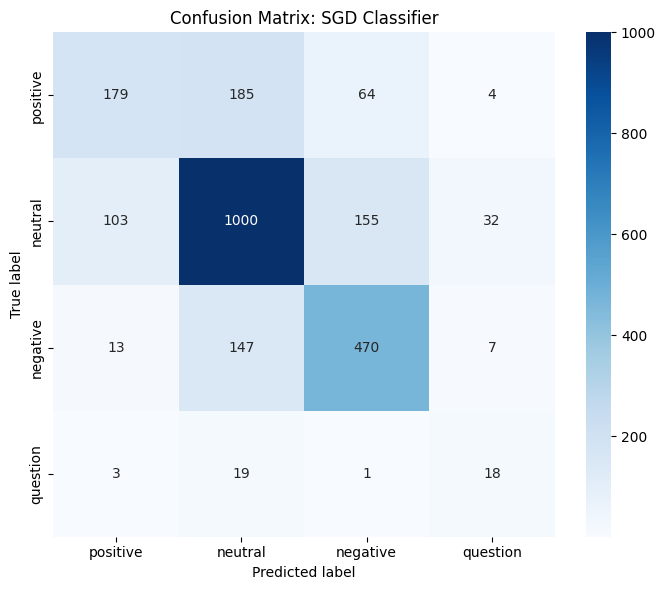

In [ ]:
#Confusion Matrix
LABEL_IDS = list(LABEL_NAMES.keys())
LABEL_TEXTS = list(LABEL_NAMES.values())

cm = confusion_matrix(
    y_val,
    best_y_pred,
    labels=LABEL_IDS
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABEL_TEXTS,
    yticklabels=LABEL_TEXTS
)

plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

In [37]:
#Error Analysis


error_df = pd.DataFrame({
  "text": X_val.reset_index(drop=True),
  "true_label": y_val.reset_index(drop=True),
  "predicted_label": pd.Series(best_y_pred)  
})

error_df["true_sentiment"] = (
    error_df["true_label"].map(LABEL_NAMES)
)

error_df["predicted_sentiment"] = (
    error_df["predicted_label"].map(LABEL_NAMES)
)

error_df = error_df[
    error_df["true_label"] != error_df["predicted_label"]
].copy()

display(error_df.head(30))



,text,true_label,predicted_label,true_sentiment,predicted_sentiment
1,ยี่ห้อนี่ เขาชอบตั้งชื่อ ลงท้ายด้วย สระอา เทีย...,0,1,positive,neutral
3,น้องแสงโสมอี้บ๋อ กะว่าน้องโซดา น้ำแข็งดี เอ๊ะห...,0,1,positive,neutral
4,สนามบินไหนไม่แพงล่ะครับบ ชางฮี เชคแลบก๊ก เจเอฟ...,1,2,neutral,negative
9,ได้ค้าบได้ รอพอทจังก่อนน้า T^T,2,1,negative,neutral
10,จัดกันนตัวเอง,1,0,neutral,positive
12,ตามใจ รำคาญ,2,1,negative,neutral
17,เปิดพรี ETUDE MATCH TINT SET ลด50%สินค้ามีจำกั...,2,1,negative,neutral
27,อยากได้กะบะออโต้หรือรถhondajazz,0,1,positive,neutral
29,ทุกเดือน12 ยอดพี่โตขึ้นเยอะมาก เดือน12 2016 ยอ...,1,2,neutral,negative
31,อยู่แถวสยามสแควร์ มีหัวปลาให้สั่งลงไปต้มในหม้อ...,2,0,negative,positive


In [39]:
error_summary = (
    error_df.groupby(
        ["true_sentiment", "predicted_sentiment"]
    )
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(error_summary)

,true_sentiment,predicted_sentiment,count
7,positive,neutral,185
3,neutral,negative,155
0,negative,neutral,147
4,neutral,positive,103
6,positive,negative,64
5,neutral,question,32
10,question,neutral,19
1,negative,positive,13
2,negative,question,7
8,positive,question,4
